## 自动微分

In [4]:
import torch

x = torch.arange(4.0)
x

tensor([0., 1., 2., 3.])

In [5]:
x.requires_grad_(True)  # 等价于x=torch.arange(4.0,requires_grad=True)
x.grad  # 默认值是None

In [6]:
y = 2 * torch.dot(x, x)
y

tensor(28., grad_fn=<MulBackward0>)

In [7]:
y.backward()
x.grad

tensor([ 0.,  4.,  8., 12.])

In [8]:
x.grad == 4 * x

tensor([True, True, True, True])

In [9]:
# 在默认情况下，PyTorch会累积梯度，我们需要清除之前的值
x.grad.zero_()
y = x.sum()
y.backward()
x.grad

tensor([1., 1., 1., 1.])

In [10]:
# 对非标量调用backward需要传入一个gradient参数，该参数指定微分函数关于self的梯度。
# 本例只想求偏导数的和，所以传递一个1的梯度是合适的
x.grad.zero_()
y = x * x
# 等价于y.backward(torch.ones(len(x)))
y.sum().backward()
x.grad

tensor([0., 2., 4., 6.])

In [11]:
x.grad == 4 * x

tensor([ True, False, False, False])

In [12]:
# 在默认情况下，PyTorch会累积梯度，我们需要清除之前的值
x.grad.zero_()
y = x.sum()
y.backward()
x.grad

tensor([1., 1., 1., 1.])

In [13]:
# 对非标量调用backward需要传入一个gradient参数，该参数指定微分函数关于self的梯度。
# 本例只想求偏导数的和，所以传递一个1的梯度是合适的
x.grad.zero_()
y = x * x
# 等价于y.backward(torch.ones(len(x)))
y.sum().backward()
x.grad

tensor([0., 2., 4., 6.])

In [14]:
# detach截断了输出,将其作为了一个标量
x.grad.zero_()
y = x * x
u = y.detach()
z = u * x

z.sum().backward()
x.grad == u

tensor([True, True, True, True])

In [15]:
def f(a):
    b = a * 2
    while b.norm() < 1000:
        b = b * 2
    if b.sum() > 0:
        c = b
    else:
        c = 100 * b
    return c

In [16]:
a = torch.randn(size=(), requires_grad=True)
d = f(a)
d.backward()
a.grad == d/a

tensor(True)

## 练习

1. 信息量更大(还有一阶的数据,因为要用,无法释放),算子要实现二阶导

In [17]:
# 练习2
# import torch

# x = torch.tensor(2.0, requires_grad=True)
# y = x ** 3

# y.backward()       # 第一次:正常,x.grad = 3x² = 12
# print(x.grad)      # tensor(12.)

# y.backward()       # 第二次:直接 RuntimeError ❌

3. 

In [18]:
# 练习4不写了,懒得想了

In [19]:
%matplotlib inline
from matplotlib_inline import backend_inline
import matplotlib.pyplot as plt
# 练习5
def use_svg_display(): 
    """使用svg格式在Jupyter中显示绘图(只在notebook中有效)"""
    backend_inline.set_matplotlib_formats('svg')

def set_figsize(figsize=(3.5, 2.5)):
    """设置matplotlib的图表大小（纯matplotlib版）"""
    plt.rcParams['figure.figsize'] = figsize


def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    """设置matplotlib的轴"""
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    # 定义刻度类型
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    axes.set_xticks([i * torch.pi for i in range(4)]) 
    # 定义显示范围
    axes.set_xlim(xlim)
    axes.set_ylim(ylim)
    # 显示图例(即左上的线条与线的对应)
    if legend:
        axes.legend(legend)
    axes.grid()


def plot(X, Y=None, xlabel=None, ylabel=None, legend=None, xlim=None,
         ylim=None, xscale='linear', yscale='linear',
         fmts=('-', 'm--', 'g-.', 'r:'), figsize=(3.5, 2.5), axes=None):
    """绘制数据点（纯matplotlib版，不依赖d2l）"""
    if legend is None:
        legend = []

    set_figsize(figsize)
    # 检查有无坐标系,没有坐标系就用当前的坐标系
    axes = axes if axes else plt.gca()

    # 如果X有一个轴，输出True
    def has_one_axis(X):
        return (hasattr(X, "ndim") and X.ndim == 1 or isinstance(X, list)
                and not hasattr(X[0], "__len__"))

    if has_one_axis(X):
        X = [X]
    if Y is None:
        X, Y = [[]] * len(X), X
    elif has_one_axis(Y):
        Y = [Y]
    if len(X) != len(Y):
        X = X * len(Y)
    # 清空坐标系
    axes.cla()
    # fmt是线的样式
    for x, y, fmt in zip(X, Y, fmts):
        if len(x):
            axes.plot(x, y, fmt)
        else:
            axes.plot(y, fmt)
    set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend)

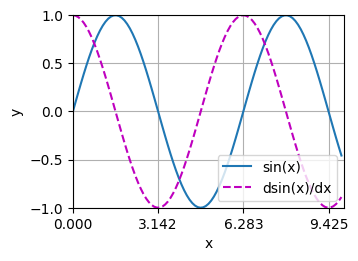

In [20]:
def fsin(x):
    return torch.sin(x)

x = torch.arange(0, 10, 0.1)
x.requires_grad_(True)
y = fsin(x)
y.sum().backward()
z = x.grad
plot(x.detach().numpy(),[y.detach().numpy(),z.detach().numpy()],legend=['sin(x)','dsin(x)/dx'],xlabel='x',ylabel='y',xlim=[0,10],ylim=[-1,1])
